<a href="https://colab.research.google.com/github/JxssDuar/CharlieFlow.github.io/blob/main/PROYECTO_FINAL_%F0%9F%91%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fase 1: Importación de Librerías
# Aquí cargamos todas las herramientas que necesitamos para nuestro proyecto.

import pandas as pd  # Para manejar los datos del archivo CSV.
from sklearn.model_selection import train_test_split  # Para dividir los datos en entrenamiento y prueba.
from sklearn.linear_model import LogisticRegression  # Nuestro modelo de Machine Learning.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Para evaluar el modelo.
import seaborn as sns  # Para crear gráficos más atractivos.
import matplotlib.pyplot as plt  # La base para los gráficos de Seaborn.
import numpy as np # Necesaria para operaciones numéricas avanzadas.

In [ ]:
# Fase 2: Carga y Preparación de Datos
# El objetivo es leer el dataset y prepararlo para que el modelo pueda entenderlo.

# Cargamos el dataset desde el archivo CSV.
df = pd.read_csv('Clash Royale Top Battles v1.csv')

# Eliminamos la primera columna 'Unnamed: 0' que es solo un índice repetido y no aporta información.
df = df.drop(columns=['Unnamed: 0'])

# Creamos nuestra variable objetivo 'p1_wins'. Será 1 si el jugador 1 tiene más coronas (gana) y 0 en caso contrario.
# Esta es la respuesta que nuestro modelo intentará predecir.
df['p1_wins'] = (df['p1_crowns'] > df['p2_crowns']).astype(int)

# Identificamos todas las columnas que contienen cartas de ambos jugadores.
card_columns = [f'p{player}_{i}' for player in [1, 2] for i in range(1, 9)]

# Obtenemos una lista de todas las cartas únicas que existen en el dataset para crear nuestras características.
all_cards = pd.unique(df[card_columns].values.ravel('K'))

# Creamos un nuevo DataFrame para las características, con una columna por cada carta única.
# Aquí es donde representaremos la batalla en un formato numérico.
features_df = pd.DataFrame(0, index=df.index, columns=all_cards)

# Llenamos el DataFrame: +1 si la carta es del Jugador 1, -1 si es del Jugador 2.
# Este es el paso clave de "Ingeniería de Características" para capturar el enfrentamiento de mazos.
for i in range(1, 9):
    for card in features_df.columns:
        p1_has_card = (df[f'p1_{i}'] == card)
        p2_has_card = (df[f'p2_{i}'] == card)
        features_df.loc[p1_has_card, card] += 1
        features_df.loc[p2_has_card, card] -= 1

# Definimos nuestras variables: X (las características, es decir, los mazos) e y (el objetivo, es decir, quién ganó).
X = features_df
y = df['p1_wins']

Visualizando la distribución de victorias...


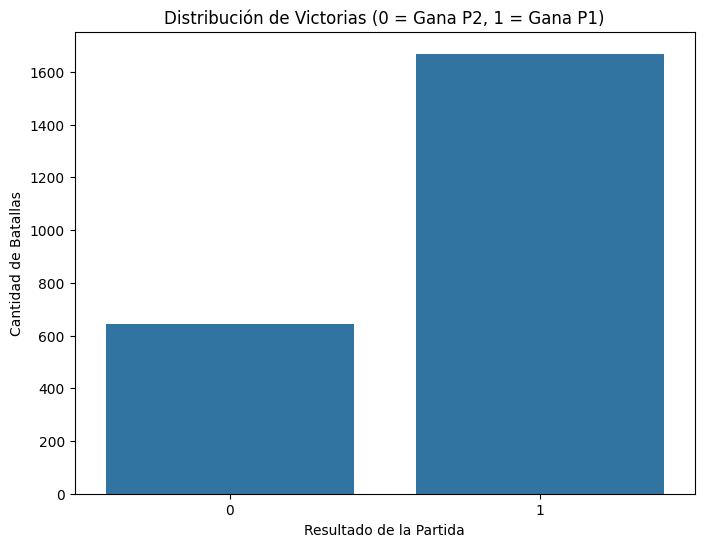

In [ ]:
# Fase 3: Exploración de Datos (Visualización)
# Antes de entrenar, vemos cómo están distribuidos nuestros datos para asegurarnos de que no haya un sesgo evidente.

print("Visualizando la distribución de victorias...")
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribución de Victorias (0 = Gana P2, 1 = Gana P1)')
plt.xlabel('Resultado de la Partida')
plt.ylabel('Cantidad de Batallas')
plt.show()

In [ ]:
# Fase 4: Entrenamiento del Modelo de Regresión Logística
# Aquí dividimos los datos y le enseñamos al modelo a encontrar patrones.

# Dividimos los datos: 80% para entrenar el modelo y 20% para probar su rendimiento.
# 'random_state=42' asegura que la división sea siempre la misma, para que los resultados sean reproducibles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Creamos una instancia de nuestro modelo de Regresión Logística.
model = LogisticRegression(max_iter=1000) # Usamos max_iter=1000 para asegurar que el modelo tenga suficientes iteraciones para converger.

# Entrenamos el modelo con los datos de entrenamiento.
# En este paso, el modelo "aprende" las relaciones entre las combinaciones de cartas y los resultados de las partidas.
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Precisión del Modelo: 70.41%

Reporte de Clasificación:
              precision    recall  f1-score   support

     Gana P2       0.36      0.08      0.13       129
     Gana P1       0.73      0.95      0.82       334

    accuracy                           0.70       463
   macro avg       0.54      0.51      0.47       463
weighted avg       0.62      0.70      0.63       463



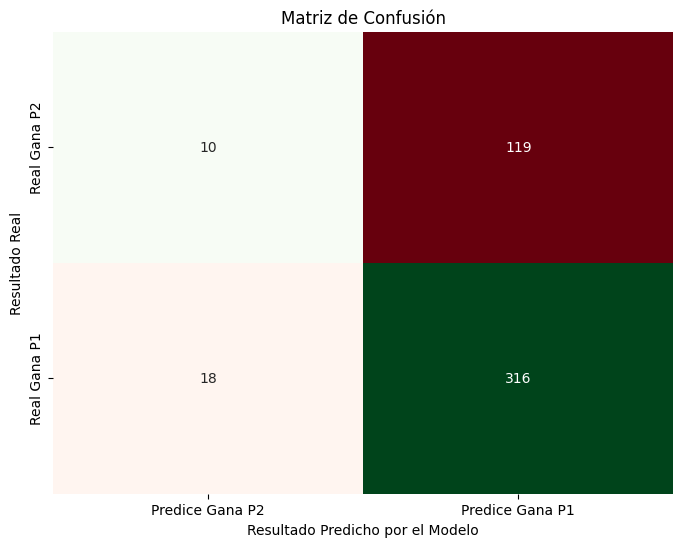

In [ ]:
# Fase 5: Evaluación del Modelo
# Verificamos qué tan bien aprendió el modelo usando los datos de prueba que nunca antes había visto.

# El modelo hace sus predicciones sobre los datos de prueba.
y_pred = model.predict(X_test)

# Calculamos la precisión (accuracy): el porcentaje de predicciones correctas.
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del Modelo: {accuracy:.2%}\n")

# Mostramos un reporte más detallado con precisión, recall y f1-score.
# Esto nos da una visión más completa del rendimiento, especialmente sobre cómo predice cada clase (victoria o derrota).
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Gana P2', 'Gana P1']))

# Creamos una Matriz de Confusión para visualizar los aciertos y errores del modelo.

cm = confusion_matrix(y_test, y_pred)
mask_aciertos = np.eye(cm.shape[0], dtype=bool)

plt.figure(figsize=(8, 6))

# Errores en rojo
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
           mask=mask_aciertos, cbar=False,
           xticklabels=['Predice Gana P2', 'Predice Gana P1'],
           yticklabels=['Real Gana P2', 'Real Gana P1'])

# Aciertos en verde
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
           mask=~mask_aciertos, cbar=False,
           xticklabels=['Predice Gana P2', 'Predice Gana P1'],
           yticklabels=['Real Gana P2', 'Real Gana P1'])

plt.title('Matriz de Confusión')
plt.ylabel('Resultado Real')
plt.xlabel('Resultado Predicho por el Modelo')
plt.show()
#Recall (Sensibilidad) #Precisión (Accuracy): #weighted avg (promedioponderada)

In [ ]:
# Fase 6: Demo Funcional - Predicción de una Batalla Específica
# Creamos una función para usar nuestro modelo en la práctica con dos mazos cualesquiera.

def predecir_victoria(mazo1, mazo2, modelo, todas_las_cartas):
    """
    Toma dos mazos (listas de cartas), los convierte al formato numérico
    y utiliza el modelo entrenado para predecir la probabilidad de victoria.
    """
    # Creamos el vector de características para esta batalla, inicialmente con todos los valores en 0.
    input_features = pd.DataFrame(0, index=[0], columns=todas_las_cartas)

    # Asignamos +1 a las cartas del mazo 1 y -1 a las del mazo 2.
    for card in mazo1:
        if card in input_features.columns:
            input_features.loc[0, card] = 1
    for card in mazo2:
        if card in input_features.columns:
            input_features.loc[0, card] = -1

    # El modelo predice las probabilidades para ambas clases (0 y 1).
    probabilidades = modelo.predict_proba(input_features)

    # La probabilidad de que gane el Jugador 1 es la segunda columna de la salida.
    prob_p1_gana = probabilidades[0][1]

    print("\n--- Predicción de Batalla ---")
    print(f"Mazo Jugador 1: {mazo1}")
    print(f"Mazo Jugador 2: {mazo2}")
    print("-" * 20)
    print(f"Probabilidad de victoria para el Jugador 1: {prob_p1_gana:.2%}")
    print(f"Probabilidad de victoria para el Jugador 2: {1 - prob_p1_gana:.2%}")
    print("-----------------------------\n")

# Ejemplo de uso con mazos de la primera fila del dataset
mazo_p1_ejemplo = ['Valkyrie', 'Magic Archer', 'Bomb Tower', 'Miner', 'Wall Breakers', 'Bats', 'The Log', 'Skeletons']
mazo_p2_ejemplo = ['X-Bow', 'Ice Spirit', 'Tesla', 'Knight', 'The Log', 'Skeletons', 'Fireball', 'Archers']
predecir_victoria(mazo_p1_ejemplo, mazo_p2_ejemplo, model, all_cards)

# Otro ejemplo
mazo_p1_ejemplo_2 = ['Mega Knight', 'Archers', 'Goblin Barrel', 'Prince', 'Zap', 'Dart Goblin', 'Goblin Gang', 'Cannon Cart']
mazo_p2_ejemplo_2 = ['Graveyard', 'Ice Wizard', 'Baby Dragon', 'Barbarian Barrel', 'Tombstone', 'Knight', 'Tornado', 'Poison']
predecir_victoria(mazo_p1_ejemplo_2, mazo_p2_ejemplo_2, model, all_cards)

mazo_p1_ejemplo_3 = ['X-Bow', 'Ice Spirit', 'Tesla', 'Knight', 'The Log', 'Skeletons', 'Fireball', 'Archers']
mazo_p2_ejemplo_3 = ['Mega Knight', 'Archers', 'Goblin Barrel', 'Prince', 'Zap', 'Dart Goblin', 'Goblin Gang', 'Cannon Cart']
predecir_victoria(mazo_p1_ejemplo_3, mazo_p2_ejemplo_3, model, all_cards)

# Ejemplo 3: Un enfrentamiento clásico de "Hog 2.6 Cycle" vs. "Golem Beatdown"
#mazo_p1_ejemplo_3 = ['Hog Rider', 'Musketeer', 'Ice Golem', 'Ice Spirit', 'Skeletons', 'Cannon', 'The Log', 'Fireball']
#mazo_p2_ejemplo_3 = ['Golem', 'Night Witch', 'Baby Dragon', 'Lumberjack', 'Mega Minion', 'Tornado', 'Barbarian Barrel', 'Lightning']
#predecir_victoria(mazo_p1_ejemplo_3, mazo_p2_ejemplo_3, model, all_cards)

# Ejemplo 4: Un mazo popular de "Log Bait" vs. un arquetipo de "Giant Graveyard"
#mazo_p1_ejemplo_4 = ['Princess', 'Goblin Barrel', 'Knight', 'The Log', 'Rocket', 'Inferno Tower', 'Goblin Gang', 'Ice Spirit']
#mazo_p2_ejemplo_4 = ['Giant', 'Graveyard', 'Musketeer', 'Skeletons', 'Poison', 'The Log', 'Barbarian Barrel', 'Cannon Cart']
#predecir_victoria(mazo_p1_ejemplo_4, mazo_p2_ejemplo_4, model, all_cards)



--- Predicción de Batalla ---
Mazo Jugador 1: ['Valkyrie', 'Magic Archer', 'Bomb Tower', 'Miner', 'Wall Breakers', 'Bats', 'The Log', 'Skeletons']
Mazo Jugador 2: ['X-Bow', 'Ice Spirit', 'Tesla', 'Knight', 'The Log', 'Skeletons', 'Fireball', 'Archers']
--------------------
Probabilidad de victoria para el Jugador 1: 70.07%
Probabilidad de victoria para el Jugador 2: 29.93%
-----------------------------


--- Predicción de Batalla ---
Mazo Jugador 1: ['Mega Knight', 'Archers', 'Goblin Barrel', 'Prince', 'Zap', 'Dart Goblin', 'Goblin Gang', 'Cannon Cart']
Mazo Jugador 2: ['Graveyard', 'Ice Wizard', 'Baby Dragon', 'Barbarian Barrel', 'Tombstone', 'Knight', 'Tornado', 'Poison']
--------------------
Probabilidad de victoria para el Jugador 1: 53.30%
Probabilidad de victoria para el Jugador 2: 46.70%
-----------------------------


--- Predicción de Batalla ---
Mazo Jugador 1: ['X-Bow', 'Ice Spirit', 'Tesla', 'Knight', 'The Log', 'Skeletons', 'Fireball', 'Archers']
Mazo Jugador 2: ['Mega Kn